<a href="https://colab.research.google.com/github/nauval135zabidi-collab/UTS_CITRA_DIGITAL/blob/main/SOAL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving img.jpg to img.jpg
Rata-rata pixel:
Original : 178.95648372343288
LPF      : 178.95314321585508
HPF      : 6.867029862792575
BPF      : 179.34190879741726


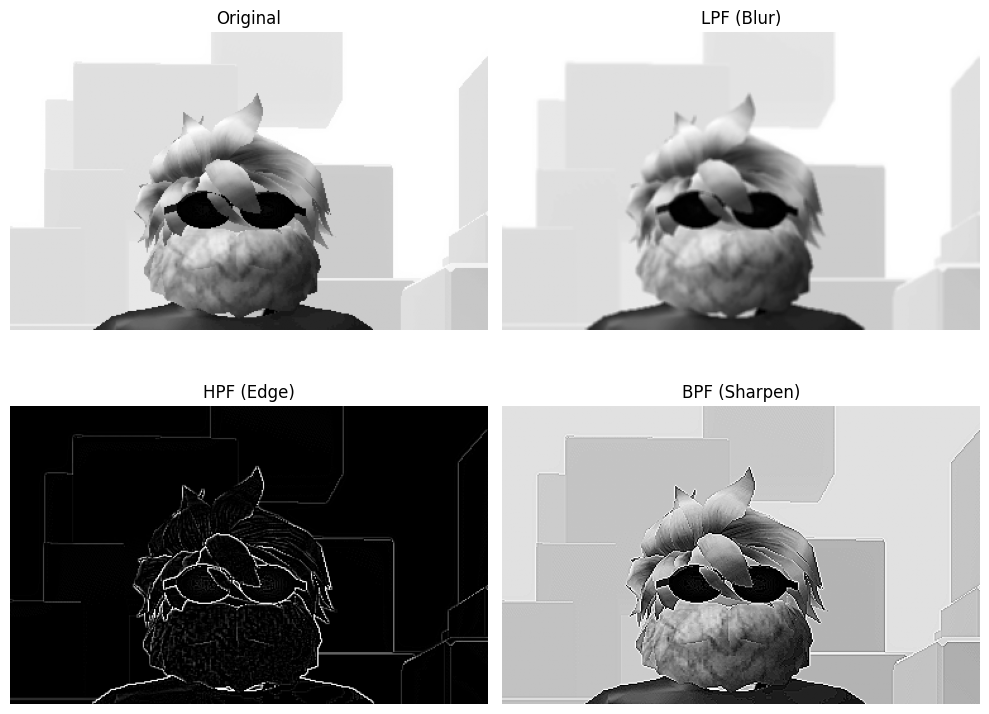

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload gambar
from google.colab import files
uploaded = files.upload()

# Baca gambar grayscale
filename = list(uploaded.keys())[0]
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# --- Kernel ---
# LPF (Low Pass Filter - blur)
kernel_lpf = (1/9) * np.array([[1,1,1],
                               [1,1,1],
                               [1,1,1]])

# HPF (High Pass Filter - edge detection)
kernel_hpf = np.array([[-1,-1,-1],
                       [-1, 8,-1],
                       [-1,-1,-1]])

# BPF (Band Pass / Sharpening)
kernel_bpf = np.array([[ 0,-1, 0],
                       [-1, 5,-1],
                       [ 0,-1, 0]])

# --- Konvolusi ---
lpf = cv2.filter2D(img, -1, kernel_lpf)
hpf = cv2.filter2D(img, -1, kernel_hpf)
bpf = cv2.filter2D(img, -1, kernel_bpf)

# --- Nilai rata-rata ---
mean_original = np.mean(img)
mean_lpf = np.mean(lpf)
mean_hpf = np.mean(hpf)
mean_bpf = np.mean(bpf)

print("Rata-rata pixel:")
print("Original :", mean_original)
print("LPF      :", mean_lpf)
print("HPF      :", mean_hpf)
print("BPF      :", mean_bpf)

# --- Tampilkan gambar ---
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("LPF (Blur)")
plt.imshow(lpf, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("HPF (Edge)")
plt.imshow(hpf, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("BPF (Sharpen)")
plt.imshow(bpf, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()